# 1. Uvod v DPS (v delu)

Ta zvezek razširi vaše **1. poglavje** z interaktivnimi prikazi, nalogami in rešitvami.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import lfilter
from scipy.io import wavfile

from IPython.display import display, Audio, clear_output

import ipywidgets as widgets
from ipywidgets import interact,FloatSlider, IntSlider, Checkbox



plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True

# Diskretna sinusoida — časovna in frekvenčna predstavitev (DPS)

**Model diskretne sinusoide (časovna domena)**
$$
x[n] \;=\; A \,\sin\!\Big(2\pi\,\frac{F_o}{F_s},{n} + \vartheta),
\qquad n=0,1,\dots,N-1.
$$

**Periode in vzorci na periodo**
$$
T_s=\frac{1}{F_s},\qquad T_o=\frac{1}{F_o},\qquad
\text{vzorci na periodo} \;=\; \frac{T_o}{T_s} \;=\; \frac{F_s}{F_o}.
$$

**Nyquistova frekvenca in aliasing**
$$
F_\mathrm{Nyq}=\frac{F_s}{2},\qquad
\text{aliasing nastopi, ko}\; F_o \ge F_\mathrm{Nyq}.
$$

**Tipična formula za alias frekvenco** (zrcaljenje v osnovni pas):
$$
F_{\text{alias}}
\;=\;\Bigl|\,F_o - k\,F_s\,\Bigr|,
\quad \text{kjer } k=\operatorname*{round}\!\Bigl(\frac{F_o}{F_s}\Bigr),
\quad F_{\text{alias}}\in[0,\,F_s/2].
$$

**Frekvenčna predstavitev (FFT; enostranska magnituda)**
Naj bo $M$ dolžina FFT (z ničelnim dopolnjevanjem po potrebi).
$$
X[k]=\sum_{n=0}^{M-1} x[n]\,e^{-j2\pi \frac{k}{M}n},
\qquad k=0,1,\dots,\tfrac{M}{2}.
$$

**Oznaka frekvenčnih točk v Hz in normalizirano**
$$
f[k]=\frac{k}{M}\,F_s,
\qquad
\omega[k]=2\pi\,\frac{f[k]}{F_s}=2\pi\,\frac{k}{M}.
$$

**Opombe za laboratorij**
- Pri stalnih $F_s$ in $A$ spreminjaj $F_o$ in $\varphi$ ter opazuj časovni signal in položaj vrhov v spektru.
- Ko $F_o\to F_s/2$, se komponenta približa Nyquistovi meji; za $F_o\ge F_s/2$ opazuj $F_{\text{alias}}$.
- “Uhajanje” (leakage) se zmanjša, če frekvenca sovpada s pozicijo diskretnih točk v FFT: $F_o/F_s = k/M$ (celi $k$).

In [2]:
# Interaktivna časovna + frekvenčna analiza (stem + FFT) z označitvijo aliasinga
# import numpy as np, matplotlib.pyplot as plt
# import ipywidgets as widgets
# from ipywidgets import FloatSlider, IntSlider, Checkbox
# from IPython.display import display, clear_output

# Parametri (Fs, Fo, A, phi, N) + M za FFT
DEFAULTS = dict(Fs=8000.0, Fo=1000.0, A=1.0, phi=0.0, N=128, M=1024)

Fs  = FloatSlider(min=1000, max=8000.0, step=100.0, value=DEFAULTS['Fs'],  description='Fs [Hz]')
Fo  = FloatSlider(min=0.0,   max=20000, step=100,   value=DEFAULTS['Fo'],  description='Fo [Hz]')
A   = FloatSlider(min=0.1,   max=5.0,    step=0.1,   value=DEFAULTS['A'],   description='A')
phi = FloatSlider(min=-np.pi, max=np.pi, step=0.05,  value=DEFAULTS['phi'], description='ϕ [rad]')
N   = IntSlider(min=64, max=2048, step=64, value=DEFAULTS['N'], description='N (čas)')
M   = IntSlider(min=256, max=16384, step=256, value=DEFAULTS['M'], description='M (FFT)')

# Novi preklopi za časovni prikaz
Show_line = Checkbox(value=False, description='Črta skozi vzorce')
Show_ZOH  = Checkbox(value=False, description='ZOH (hold)')

out = widgets.Output()

def redraw(_=None):
    with out:
        clear_output(wait=True)

        # ---- Signal v času ----
        n = np.arange(N.value)
        x = A.value*np.sin(2*np.pi*Fo.value*n/Fs.value + phi.value)
        T = 1.0/Fs.value

        # ---- FFT (enostranska) ----
        X = np.fft.rfft(x, n=M.value)
        f = np.fft.rfftfreq(M.value, d=1.0/Fs.value)
        mag = np.abs(X)

        # ---- Aliasing marker ----
        nyq = Fs.value/2
        alias = None
        if Fo.value > nyq:
            # f_alias = |Fo - round(Fo/Fs)*Fs|, prisilimo v [0, Fs/2]
            k = int(np.round(Fo.value/Fs.value))
            alias = abs(Fo.value - k*Fs.value)
            if alias > nyq:
                alias = abs(Fs.value - alias)

        # ---- Risanje: 2 vrsti (čas zgoraj, FFT spodaj) ----
        plt.close('all')
        fig, (ax_t, ax_f) = plt.subplots(2, 1, figsize=(9.5, 6.5), constrained_layout=True)

        # (1) ČASOVNI PRIKAZ — stem
        marker, stems, base = ax_t.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt='k-')
        marker.set_markersize(5.0)

        # opcijska črta
        if Show_line.value:
            ax_t.plot(n, x, color='C0', alpha=0.35, lw=1.0)

        # opcijski ZOH
        if Show_ZOH.value and N.value > 1:
            t_s   = n * T
            t_zoh = np.repeat(t_s, 2)[1:]
            t_zoh = np.concatenate(([t_s[0]], t_zoh, [t_s[-1] + T]))
            x_zoh = np.repeat(x, 2)
            ax_t.plot(t_zoh / T, x_zoh, color='C3', lw=1.2, alpha=0.9, label='ZOH')
            ax_t.legend(loc='upper right')

        ax_t.set_title(
            'Časovna domena (diskretni stem):  x[n] = A·sin(2π·Fo/Fs·n + ϕ)\n'
            f'Fs={Fs.value:.0f} Hz, Fo={Fo.value:.1f} Hz, A={A.value:.2f}, ϕ={phi.value:.2f} rad, N={N.value}'
        )
        ax_t.set_xlabel('n [vzorec]')
        ax_t.set_ylabel('amplituda')
        ax_t.grid(True, ls=':')

        # sekundarna os v sekundah (zgoraj)
        def n_to_t(nvals): return nvals * T
        def t_to_n(tvals): return tvals / T
        try:
            secax = ax_t.secondary_xaxis('top', functions=(n_to_t, t_to_n))
            secax.set_xlabel('t [s]')
        except Exception:
            pass  # če backend ne podpira secondary_xaxis

        # (2) FREKVENČNI PRIKAZ — |X(f)|
        ax_f.plot(f, mag, lw=1.5)
        ax_f.set_title(
            'Magnituda FFT (|X(f)|)\n'
            f'Fs={Fs.value:.0f} Hz, Fo={Fo.value:.1f} Hz, A={A.value:.2f}, ϕ={phi.value:.2f} rad,  N={N.value}, M={M.value}'
        )
        ax_f.set_xlabel('f [Hz]')
        ax_f.set_ylabel('|X(f)|')
        ax_f.grid(True, ls=':')
        ax_f.set_xlim(0, Fs.value/2)

        # Označi Fo in po potrebi alias
        ax_f.axvline(Fo.value, color='C3', lw=1.2, ls='--', label='Fo (vhod)')
        if alias is not None:
            ax_f.axvline(alias, color='C4', lw=1.2, ls='--', label='alias')
            ax_f.text(alias, 0.95*ax_f.get_ylim()[1], f' alias ≈ {alias:.1f} Hz',
                      color='C4', ha='center', va='top', fontsize=9)
        ax_f.legend(loc='upper right')

        plt.show()

# Vezave na dogodke
for w in (Fs, Fo, A, phi, N, M, Show_line, Show_ZOH):
    w.observe(redraw, 'value')

# Prvi izris + UI
redraw()
display(
    widgets.VBox([
        widgets.HBox([Fs, Fo]),
        widgets.HBox([A, phi]),
        widgets.HBox([N, M]),
        widgets.HBox([Show_line, Show_ZOH]),
        out
    ])
)


In [3]:
@interact(freq=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='freq'))
def _risi(freq):
    x = np.linspace(0, 2*np.pi, 1000)
    y = np.sin(freq*x)
    plt.figure(figsize=(6,3))
    plt.plot(x, y)
    plt.title(f"sin({freq:.1f}*t)")
    plt.grid(True, ls=':')
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='freq', max=5.0, min=0.1), Output()), _dom_classes=('…

### Primer dodajanja odmeva: nerekurzivni (KEO/FIR) in rekurzivni (NEO/IIR) sistem



#### 1. **KEO odmev** z `N` ponovitvami, zakasnitvijo `D` (v vzorcih) in faktorjem oslabitve `g`:
$$
y[n] \;=\; \sum_{k=0}^{N} g^{k}\,x[n-kD].
$$
Odziv na enotin impulz je **končen** (KEO), zato se odmev po `N` ponovitvah konča.

Za vsak dodaten odmev postaja sistem vsebolj kompleksen za izvedbo.



#### 2. **NEO odmev** z zakasnitvijo `D` in povratno vezavo `g`:
$$
y[n] \;=\; x[n] \;+\; g\,y[n-D]
\qquad\Longleftrightarrow\qquad
H(z)\;=\;\frac{1}{1-g\,z^{-D}}.
$$
Odziv na enotin impulz je **neskončen** (NEO) in eksponentno pada, če $$|g|<1$$

Signalu doda neskončno odmevov, kar je boljši približek naravnega odmeva.

Spodnja koda:
- zgradi **FIR** odmev preko **konvolucije** z impulznim odzivom,
- izračuna **IIR** odmev z **`lfilter`** (povratna vezava v imenovalcu),
- prikaže **impulzne odzive** obeh (funkcija `stem`),
- prebere `.wav` in predvaja: **original**, **FIR**, **IIR**.


Sample rate: 22050 samples: 65968


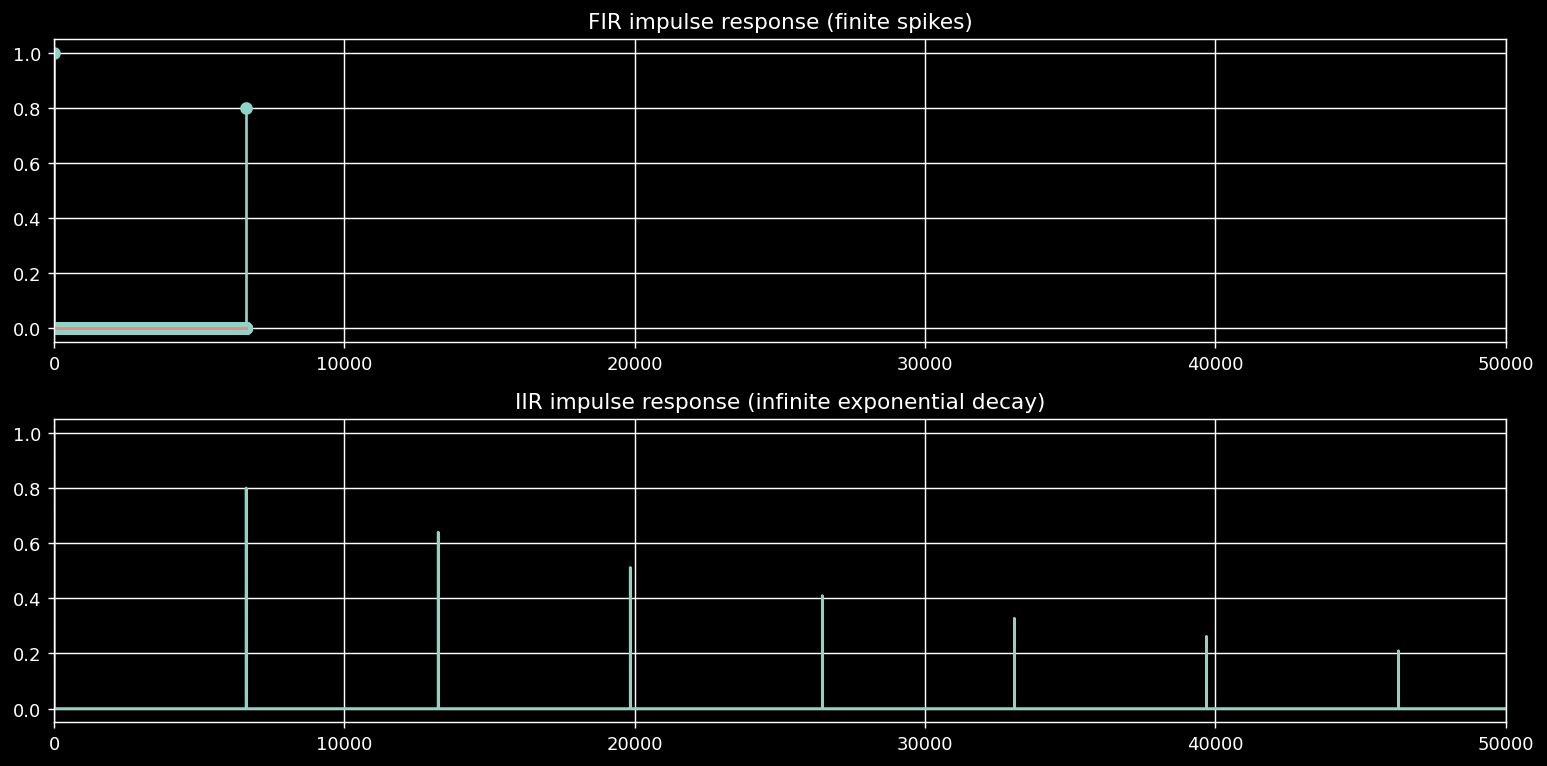

Original


FIR echo


IIR echo


In [4]:


# -------------------------
# Load WAV (mono or stereo → take left)
# -------------------------
WAV_PATH = "../../Data/Audio/danes_je_lep_dan.wav"
sr, x = wavfile.read(WAV_PATH)

# Convert to float32 [-1, 1]
x = x.astype(np.float32)
if x.dtype.kind in ('i', 'u'):
    x /= np.iinfo(np.int16).max

# Use left channel if stereo
if x.ndim > 1:
    x = x[:, 0]

print("Sample rate:", sr, "samples:", len(x))

# -------------------------
# Parameters (simple manual control)
# -------------------------
delay_sec   = 0.30
decay_fir   = 0.8
repeats_fir = 1
feedback_iir = 0.8        # |g| < 1 for stability

# -------------------------
# FIR echo using convolution
# -------------------------
D = int(delay_sec * sr)                       # delay in samples
h_fir = np.zeros(D * repeats_fir + 1)         # FIR impulse response
for k in range(repeats_fir + 1):
    h_fir[k * D] = decay_fir ** k

y_fir = np.convolve(x, h_fir)[:len(x)]

# -------------------------
# IIR echo using lfilter
# -------------------------
b = np.array([1.0])
a = np.zeros(D + 1)
a[0] = 1.0
a[-1] = -feedback_iir

y_iir = lfilter(b, a, x)

# -------------------------
# Impulse responses
# -------------------------
N = 50000                      # long visualization
imp = np.zeros(N)
imp[0] = 1.0

ir_fir = h_fir
ir_iir = lfilter(b, a, imp)

# -------------------------
# Plot impulse responses
# -------------------------
fig, axs = plt.subplots(2, 1, figsize=(12, 6))

# FIR
axs[0].stem(np.arange(len(ir_fir)), ir_fir)
axs[0].set_title("FIR impulse response (finite spikes)")
axs[0].set_xlim(0, N)
axs[0].grid(True)

# IIR
axs[1].plot(ir_iir)
axs[1].set_title("IIR impulse response (infinite exponential decay)")
axs[1].set_xlim(0, N)
axs[1].grid(True)

plt.tight_layout()
plt.show()

# -------------------------
# Playback
# -------------------------
print("Original")
display(Audio(x, rate=sr))

print("FIR echo")
display(Audio(y_fir, rate=sr))

print("IIR echo")
display(Audio(y_iir, rate=sr))

## Wave datoteka
Wave datoteka kot zapis digitalnega signala.

Na začetku se nahaja skupina podatkov o zajetju in vrsti signala, potem sledijo zajeti vzorci digitalnega signala.

In [5]:
from scipy.io import wavfile
import numpy as np
WAV_PATH = '../../Data/Audio/danes_je_lep_dan.wav'  # <- pot do .wav
try:
    Fs, x_raw = wavfile.read(WAV_PATH)
    print("=== WAV INFO (scipy) ===")
    print("Sample rate :", Fs)
    print("Shape       :", x_raw.shape, "(n, ch) if 2D; n if 1D")
    print("dtype       :", x_raw.dtype)
    if x_raw.ndim == 2:
        print("Channels    :", x_raw.shape[1])
    else:
        print("Channels    : 1 (mono)")
    # (bit-depth) rough hint from dtype:
    if x_raw.dtype == np.int16:
        print("Bit depth   : 16-bit PCM (inferred from dtype)")
    elif x_raw.dtype == np.int32:
        print("Bit depth   : 32-bit PCM (inferred from dtype)")
    elif x_raw.dtype == np.float32:
        print("Bit depth   : 32-bit float (inferred from dtype)")
    else:
        print("Bit depth   : (unknown; dtype-specific)")
except Exception as e:
    print("scipy.io.wavfile.read failed:", e)

=== WAV INFO (scipy) ===
Sample rate : 22050
Shape       : (65968,) (n, ch) if 2D; n if 1D
dtype       : int16
Channels    : 1 (mono)
Bit depth   : 16-bit PCM (inferred from dtype)
